In [2]:
import numpy as np
import pandas as pd
from reggression import Reggression
from eggp import EGGP
import matplotlib.pyplot as plt

In [3]:
def texfmt(x):
    return x

def thetafmt(x):
    return list(map(lambda y: round(float(y),2), x.split(";")))

def parfmt(x):
    if x=="nan" or (isinstance(x, float) and np.isnan(x)):
        return x
    return list(map(lambda y: round(y, 2), eval(x)))
    
def lossfmt(x):
    return f'{x:.2e}'

lossCols = ['loss_train']
eggpfmt = {'Math': texfmt, 'theta': thetafmt} | { k : lossfmt for k in lossCols }

reggfmt = {'Latex': texfmt,	'Fitness': lossfmt,	'Parameters': parfmt, 'DL': lossfmt}

In [176]:
x = np.arange(0, 10, 0.05)
y = np.exp(-x/1.2)*x**3*(np.cos(x) * np.sin(x)**2 - 3.1415) + np.random.normal(0, 0.05, x.shape)
#*np.cos(x)*np.sin(x)

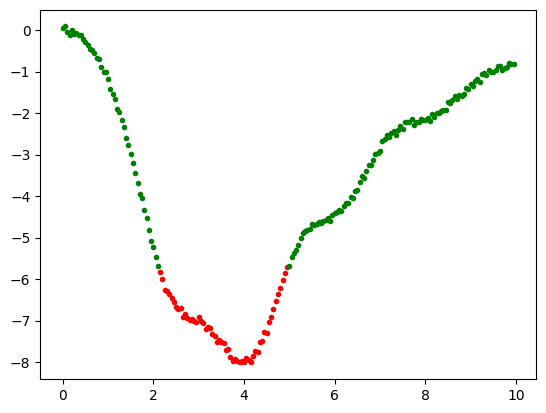

In [177]:
lb, ub = 2.1, 5
x_sel = x[(x>lb) & (x<ub)].reshape(-1,1)
y_sel = y[(x>lb) & (x<ub)]
x_ood = x[(x<=lb) | (x>=ub)].reshape(-1, 1)
y_ood = y[(x<=lb) | (x>=ub)]
plt.plot(x_sel, y_sel, '.', color='red')
plt.plot(x_ood, y_ood, '.', color='green')
plt.savefig("figs/vlads.svg")

In [178]:
df = pd.DataFrame({'x':x, 'y':y}).to_csv("vlad.csv", index=False)

In [210]:
reg = EGGP(gen=200, nPop=200, maxSize=20, nonterminals="add,sub,mul,div,log,square,cube,sin,cos,abs,sqrt,exp", simplify=True, optRepeat=2, optIter=20, folds=2, dumpTo="vlad.egg")
reg.fit(x_sel, y_sel)

,gen,200
,nPop,200
,maxSize,20
,nTournament,3
,pc,0.9
,pm,0.3
,nonterminals,"'add,sub,mul,div,log,sq...be,sin,cos,abs,sqrt,exp'"
,loss,'MSE'
,optIter,20
,optRepeat,2
,nParams,-1


In [211]:
reg.results[["Math", "size", "loss_train"]].style.format(eggpfmt)

,Math,size,loss_train
0,$$\theta_{0}$$,1,3.60e-01
1,$$\left(\theta_{0} + \operatorname{cos}(x_{0})\right)$$,4,3.19e-01
2,$$\left(\theta_{0} + \frac{\theta_{1}}{x_{0}}\right)$$,5,3.18e-01
3,$$\left(\theta_{0} + \operatorname{square}(\left(\theta_{1} - x_{0}\right))\right)$$,6,6.42e-02
4,$$\left(\left(\operatorname{cos}(x_{0}) \cdot \left(x_{0} + \theta_{0}\right)\right) + \theta_{1}\right)$$,8,4.22e-02
5,$$\left(\theta_{0} + \left(\operatorname{cos}(\left(\theta_{1} + \operatorname{cos}(x_{0})\right)) \cdot x_{0}\right)\right)$$,9,1.25e-02
6,$$\left(\theta_{0} + \left(\operatorname{cos}(\left(\theta_{1} + \operatorname{cos}(x_{0})\right)) \cdot \left(\theta_{2} \cdot x_{0}\right)\right)\right)$$,11,9.00e-03
7,$$\left(\theta_{0} + \left(\operatorname{cos}(\operatorname{cos}(x_{0})) \cdot \left(\theta_{1} \cdot \operatorname{cos}(\left(x_{0} + \theta_{2}\right))\right)\right)\right)$$,12,4.68e-03
8,$$\left(\theta_{0} - \left(\operatorname{cos}(\operatorname{cos}(x_{0})) \cdot \left(\theta_{1} \cdot \operatorname{cos}(\left |\left(x_{0} + \theta_{2}\right)\right |)\right)\right)\right)$$,13,4.81e-03
9,$$\left(\theta_{0} + \left(\operatorname{cos}(\operatorname{cos}(x_{0})) \cdot \left(\theta_{1} \cdot \operatorname{cos}(\left(\left(\theta_{2} - x_{0}\right) + \theta_{3}\right))\right)\right)\right)$$,14,5.87e-03


In [215]:
def plot_model(f, x, y):
    plt.plot(x, y, '.', alpha=0.1)
    yhat = np.clip(f(x.reshape(-1,1)), -10, 10)
    plt.plot(x, yhat)
    
def model(ix):
    def f(x):
        t = np.array(list(map(float, reg.results.iloc[ix]["theta"].split(";"))))
        return eval(reg.results.iloc[ix]["Numpy"])
    return f

In [4]:
egg = Reggression(dataset="vlad.csv", loadFrom="vlad.egg")

Calculating DL...
Welcome to r🥚ression


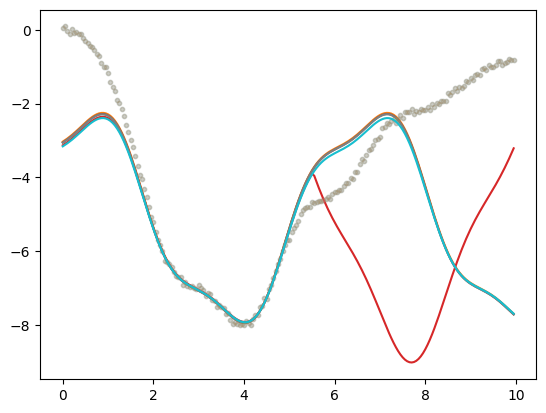

In [298]:
def model_top(res, n, x, y):
    for ix in range(n):
        def f(x):
            t = np.array(eval(res.iloc[ix]["Parameters"]))
            return eval(res.iloc[ix]["Numpy"])
        
        plot_model(f, x, y)
        
n=5
model_top(egg.top(n=n), n, x, y)
plt.savefig("figs/top5.svg")

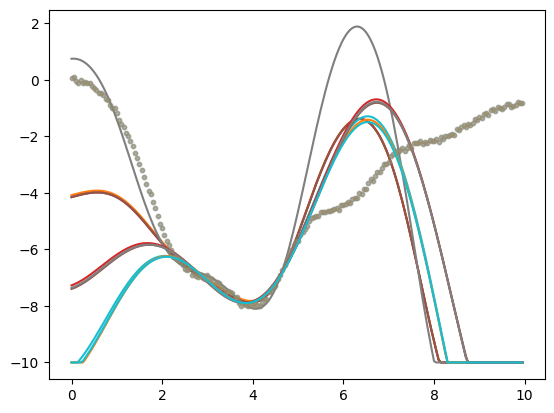

In [305]:
n=10
model_top(egg.top(n=n, filters=["size <= 10"]), n, x, y)
plt.savefig("figs/top10.svg")

In [306]:
print(egg.distributionOfTokens(top=1000).to_markdown(index=False))

| Pattern    |   Count |      AvgFit |
|:-----------|--------:|------------:|
| x0         |    2604 | -0.00359749 |
| t0         |    1006 | -0.009312   |
| t1         |     981 | -0.00941213 |
| t2         |     955 | -0.00937039 |
| t3         |     806 | -0.00893546 |
| t4         |     466 | -0.00910986 |
| t5         |     144 | -0.00786632 |
| t6         |       1 | -0.013187   |
| Abs(v0)    |     465 | -0.00810496 |
| Sin(v0)    |      74 | -0.0115615  |
| Cos(v0)    |    3029 | -0.00309273 |
| Sqrt(v0)   |      32 | -0.00845579 |
| Square(v0) |      27 | -0.00967352 |
| Log(v0)    |      10 | -0.00972384 |
| Exp(v0)    |      45 | -0.0118458  |
| Cube(v0)   |      38 | -0.00867039 |
| (v0 + v1)  |    3405 | -0.00275121 |
| (v0 - v1)  |     351 | -0.00848634 |
| (v0 * v1)  |    2139 | -0.0042415  |
| (v0 / v1)  |      68 | -0.00815694 |


<string>:1: RuntimeWarning: divide by zero encountered in log


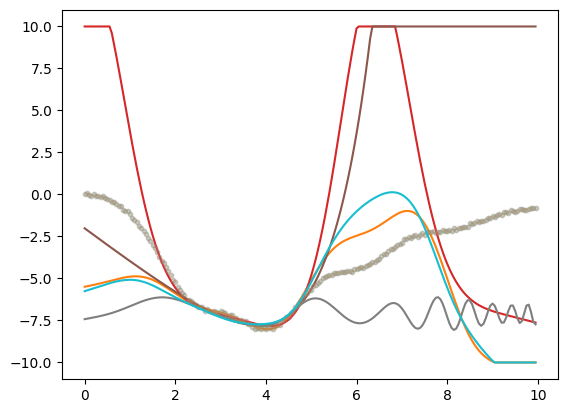

In [307]:
n=5
model_top(egg.top(n=n, pattern="exp(v0)*v1"), n, x, y)
plt.savefig("figs/top5pat.svg")

In [288]:
from pyoperon.sklearn import SymbolicRegressor
regOp = SymbolicRegressor(objectives=['mse','length'], max_length=20, allowed_symbols='add,sub,mul,div,square,sin,cos,exp,log,sqrt,abs,constant,variable')
regOp.fit(x_sel, y_sel)
f = open("equations.operon", "w")
for eq in regOp.pareto_front_:
  eqstr = regOp.get_model_string(eq['tree'])
  fitness = -eq['mean_squared_error']
  print(f"{eqstr},{fitness},{fitness}")
  print(f"{eqstr},{fitness},{fitness}", file=f)
f.close()

((-6.477) + ((-0.119) * (1.489 * X1))),-0.3895822050308636,-0.3895822050308636
((-7.064) + ((-0.845) * sin((2.089 * X1)))),-0.06773598901395281,-0.06773598901395281
((-6.853) + (1.075 * sin(exp((0.393 * X1))))),-0.03570614518660037,-0.03570614518660037
((-6.760) + ((-0.246) * ((1.254 * X1) * cos((1.688 * X1))))),-0.03515602872126632,-0.03515602872126632
((-5.886) + (0.118 * (cos((0.967 * X1)) / exp(((-0.779) * X1))))),-0.015575795634363225,-0.015575795634363225
((-7.510) + (1.815 * (sin((1.305 * X1)) + cos(cos((1.455 * X1)))))),-0.005154461016806709,-0.005154461016806709
((-7.663) + (1.944 * (sin(sin((1.307 * X1))) + cos(cos((1.479 * X1)))))),-0.0038494422754806203,-0.0038494422754806203
((-7.248) + (1.844 * (sin(sin((1.325 * X1))) + (((-0.062) * X1) + cos(cos((1.489 * X1))))))),-0.003314231428514584,-0.003314231428514584
((-6.879) + (2.401 * (((-0.050) * X1) + (sin(((1.688 * X1) / exp((0.062 * X1)))) + cos(cos((1.489 * X1))))))),-0.0028863992287698646,-0.0028863992287698646
((-7.435) 

In [289]:
egg.importFromCSV("equations.operon", False)

''

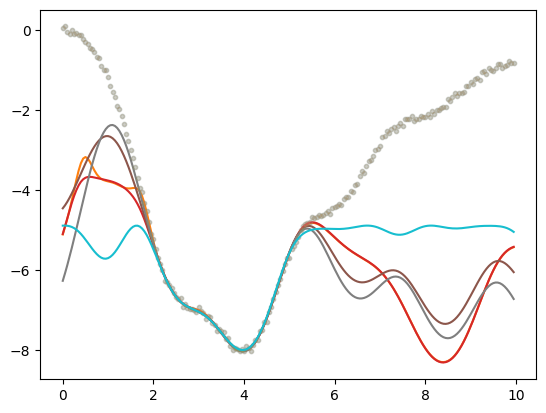

In [290]:
model_top(egg.top(n=n), n, x, y)
plt.savefig("figs/top5operon.svg")

In [24]:
result = egg.insert("((x0^3)*(cos(x0)*(sin(x0)^2)-t0)*(exp(x0/t0)))")

In [25]:
print(result[["Latex", "Fitness", "Parameters"]].to_markdown(index=False))

| Latex                                                                                                                                                                                                        |     Fitness | Parameters                                |
|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------:|:------------------------------------------|
| \begin{align}\left(\left({x^{3.0}} \cdot \left(\left(\operatorname{cos}(x) \cdot {\operatorname{sin}(x)^{2.0}}\right) + \theta_{0}\right)\right) \cdot e^{\left(x \cdot \theta_{1}\right)}\right)\end{align} | -0.00256414 | [-3.148465558722933, -0.8337182900278185] |
